<a href="https://colab.research.google.com/github/agyl05/projek-skripsi/blob/main/augmentasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install timm --quiet
!pip install torchmetrics --quiet


import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score,
    recall_score, f1_score,
    roc_auc_score, roc_curve, auc
)

warnings.filterwarnings('ignore')

# Device — gunakan GPU jika tersedia
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Semua library berhasil diimport.")
print(f"Device aktif: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 17.8 MB/s eta 0:00:00
Semua library berhasil diimport.
Device aktif: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
DATASET_DIR = '/content/drive/MyDrive/dataset_cabai'

# Cek apakah folder dataset ada
if os.path.exists(DATASET_DIR):
    print(f"Dataset ditemukan di: {DATASET_DIR}")
    print("Isi folder:")
    for folder in sorted(os.listdir(DATASET_DIR)):
        folder_path = os.path.join(DATASET_DIR, folder)
        if os.path.isdir(folder_path):
            n = len([f for f in os.listdir(folder_path)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))])
            print(f"  {folder:<20}: {n} gambar")
else:
    print(f"FOLDER TIDAK DITEMUKAN: {DATASET_DIR}")
    print("Periksa kembali nama folder di Google Drive Anda.")

Dataset ditemukan di: /content/drive/MyDrive/dataset_cabai
Isi folder:
  daun sehat          : 420 gambar
  leaf curl           : 420 gambar
  leaf spot           : 420 gambar
  whitefly            : 420 gambar
  yellowish           : 420 gambar


In [ ]:

# --- Path ---
DATASET_DIR = Path('/content/drive/MyDrive/dataset_cabai')
SAVE_DIR    = Path('/content/drive/MyDrive/hasil_skripsi')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['daun sehat', 'leaf curl', 'yellowish', 'leaf spot', 'whitefly']
NUM_CLASSES = len(CLASS_NAMES)

# --- Training ---
IMG_SIZE        = 224
BATCH_SIZE      = 32
EPOCHS_PHASE1   = 10    # Fase 1: feature extraction
EPOCHS_PHASE2   = 30    # Fase 2: fine-tuning (EarlyStopping bisa hentikan lebih awal)
PATIENCE_P1     = 5     # EarlyStopping patience Fase 1
PATIENCE_P2     = 8     # EarlyStopping patience Fase 2
LR_PHASE1       = 1e-3  # Learning rate Fase 1
LR_BACKBONE_P2  = 5e-6  # LR backbone Fase 2 (sangat kecil, GRN sensitif)
LR_HEAD_P2      = 1e-4  # LR head Fase 2
WEIGHT_DECAY    = 0.05
DROPOUT_RATE    = 0.3
RANDOM_SEED     = 42

# Set random seed agar hasil reproducible
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Konfigurasi global:")
print(f"  Kelas         : {CLASS_NAMES}")
print(f"  Jumlah kelas  : {NUM_CLASSES}")
print(f"  Image size    : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Hasil disimpan: {SAVE_DIR}")

Konfigurasi global:
  Kelas         : ['daun sehat', 'leaf curl', 'yellowish', 'leaf spot', 'whitefly']
  Jumlah kelas  : 5
  Image size    : 224x224
  Batch size    : 32
  Hasil disimpan: /content/drive/MyDrive/hasil_skripsi


TAHAP 1 — DATA ACQUISITION
  daun sehat        :   420 gambar
  leaf curl         :   420 gambar
  yellowish         :   420 gambar
  leaf spot         :   420 gambar
  whitefly          :   420 gambar

  Total keseluruhan: 2100 gambar
  Rasio imbalance  : 1.00x  (daun sehat vs daun sehat)


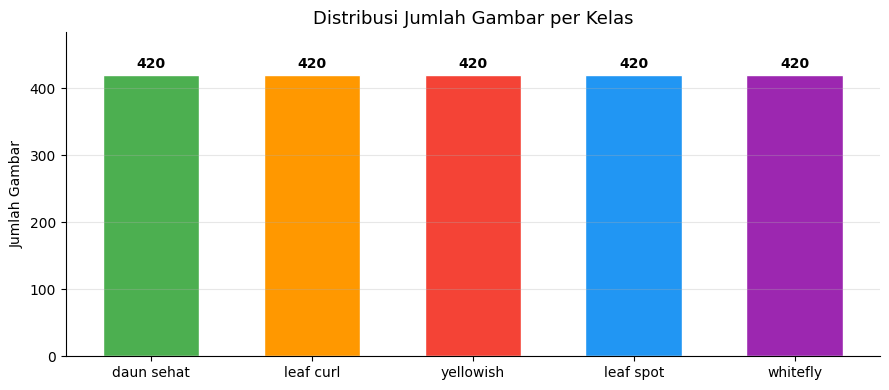

  Grafik disimpan: distribusi_kelas.png


In [ ]:


print("="*50)
print("TAHAP 1 — DATA ACQUISITION")
print("="*50)

class_counts = {}
total = 0

for cls in CLASS_NAMES:
    folder = DATASET_DIR / cls
    if folder.exists():
        imgs = (list(folder.glob('*.jpg')) +
                list(folder.glob('*.jpeg')) +
                list(folder.glob('*.png')))
        class_counts[cls] = len(imgs)
        total += len(imgs)
        print(f"  {cls:<18}: {len(imgs):>5} gambar")
    else:
        print(f"  [ERROR] Folder tidak ditemukan: {folder}")

print(f"\n  Total keseluruhan: {total} gambar")

# Deteksi class imbalance
if class_counts:
    max_cls  = max(class_counts, key=class_counts.get)
    min_cls  = min(class_counts, key=class_counts.get)
    ratio    = class_counts[max_cls] / class_counts[min_cls]
    print(f"  Rasio imbalance  : {ratio:.2f}x  ({max_cls} vs {min_cls})")
    if ratio > 3:
        print("  [INFO] Dataset tidak seimbang — class weighting akan diterapkan saat training.")

# Visualisasi distribusi kelas
fig, ax = plt.subplots(figsize=(9, 4))
labels  = [c.replace('_', ' ') for c in CLASS_NAMES]
counts  = [class_counts.get(c, 0) for c in CLASS_NAMES]
colors  = ['#4CAF50','#FF9800','#F44336','#2196F3','#9C27B0']
bars    = ax.bar(labels, counts, color=colors, edgecolor='white', width=0.6)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Distribusi Jumlah Gambar per Kelas', fontsize=13)
ax.set_ylabel('Jumlah Gambar')
ax.set_ylim(0, max(counts) * 1.15)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'distribusi_kelas.png', dpi=150)
plt.show()
print("  Grafik disimpan: distribusi_kelas.png")

In [ ]:

print("="*50)
print("TAHAP 2 — DATA CLEANING")
print("="*50)

valid_paths   = []   # list of (path_string, label_index)
removed_total = 0

for label_idx, cls in enumerate(CLASS_NAMES):
    folder = DATASET_DIR / cls
    if not folder.exists():
        continue
    all_imgs = (list(folder.glob('*.jpg')) +
                list(folder.glob('*.jpeg')) +
                list(folder.glob('*.png')))
    valid = 0
    removed = 0
    for img_path in all_imgs:
        try:
            with Image.open(img_path) as img:
                img.verify()
            with Image.open(img_path) as img:
                img.convert('RGB')
            valid_paths.append((str(img_path), label_idx))
            valid += 1
        except Exception:
            removed += 1
    removed_total += removed
    print(f"  {cls:<18}: {valid:>5} valid  |  {removed} dihapus")

print(f"\n  Total valid : {len(valid_paths)} gambar")
print(f"  Total rusak : {removed_total} gambar")
print("  Data cleaning selesai.")

TAHAP 2 — DATA CLEANING
  daun sehat        :   420 valid  |  0 dihapus
  leaf curl         :   420 valid  |  0 dihapus
  yellowish         :   420 valid  |  0 dihapus
  leaf spot         :   420 valid  |  0 dihapus
  whitefly          :   420 valid  |  0 dihapus

  Total valid : 2100 gambar
  Total rusak : 0 gambar
  Data cleaning selesai.


In [ ]:

print("="*50)
print("TAHAP 3 — DATA SPLITTING")
print("="*50)

all_paths  = [p for p, _ in valid_paths]
all_labels = [l for _, l in valid_paths]

# Split 1: 80% train vs 20% sementara
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.20, stratify=all_labels, random_state=RANDOM_SEED
)

# Split 2: dari 20% → 10% val dan 10% test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.50, stratify=temp_labels, random_state=RANDOM_SEED
)

n_total = len(all_paths)
print(f"  Training   : {len(train_paths):>5} gambar  ({len(train_paths)/n_total*100:.1f}%)")
print(f"  Validation : {len(val_paths):>5} gambar  ({len(val_paths)/n_total*100:.1f}%)")
print(f"  Testing    : {len(test_paths):>5} gambar  ({len(test_paths)/n_total*100:.1f}%)")

print("\n  Distribusi kelas di Training set:")
train_dist = Counter(train_labels)
for idx, cls in enumerate(CLASS_NAMES):
    print(f"    {cls:<18}: {train_dist[idx]}")

TAHAP 3 — DATA SPLITTING
  Training   :  1680 gambar  (80.0%)
  Validation :   210 gambar  (10.0%)
  Testing    :   210 gambar  (10.0%)

  Distribusi kelas di Training set:
    daun sehat        : 336
    leaf curl         : 336
    yellowish         : 336
    leaf spot         : 336
    whitefly          : 336


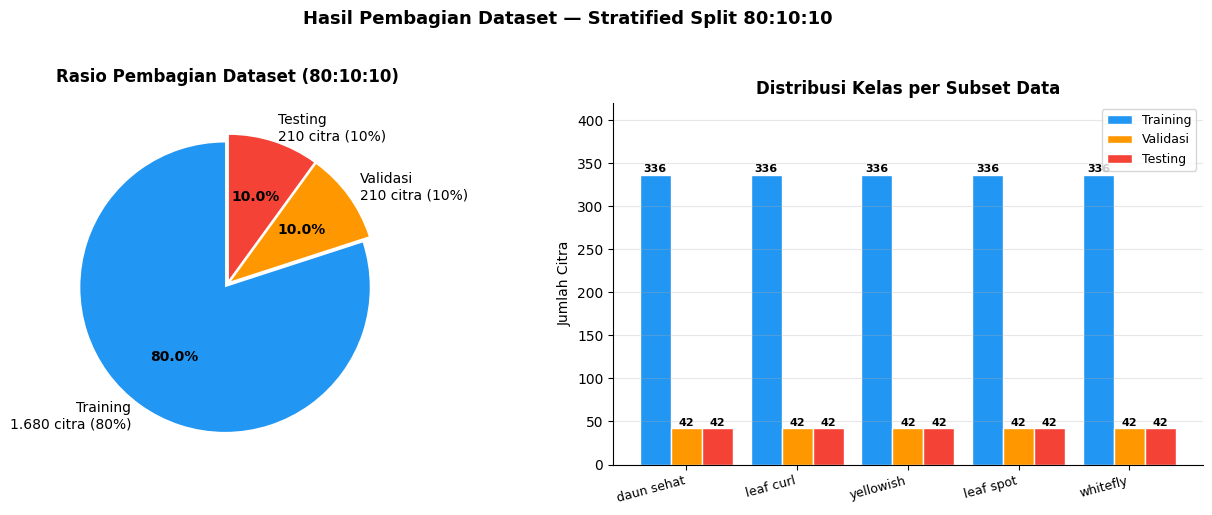

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel kiri: Pie chart rasio pembagian
sizes  = [len(train_paths), len(val_paths), len(test_paths)]
labels = [f'Training\n1.680 citra (80%)',
          f'Validasi\n210 citra (10%)',
          f'Testing\n210 citra (10%)']
colors  = ['#2196F3', '#FF9800', '#F44336']
explode = (0.03, 0.03, 0.03)

wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=colors,
    explode=explode, autopct='%1.1f%%',
    startangle=90, textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[0].set_title('Rasio Pembagian Dataset (80:10:10)',
                  fontsize=12, fontweight='bold', pad=15)

# Panel kanan: Bar chart distribusi kelas per subset
from collections import Counter
train_c = Counter(train_labels)
val_c   = Counter(val_labels)
test_c  = Counter(test_labels)

x      = range(NUM_CLASSES)
width  = 0.28
labels_k = [c.replace('_', ' ') for c in CLASS_NAMES]

b1 = axes[1].bar([i - width for i in x],
                 [train_c[j] for j in range(NUM_CLASSES)],
                 width, label='Training', color='#2196F3', edgecolor='white')
b2 = axes[1].bar([i for i in x],
                 [val_c[j] for j in range(NUM_CLASSES)],
                 width, label='Validasi',  color='#FF9800', edgecolor='white')
b3 = axes[1].bar([i + width for i in x],
                 [test_c[j] for j in range(NUM_CLASSES)],
                 width, label='Testing',   color='#F44336', edgecolor='white')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     h + 1, str(int(h)),
                     ha='center', va='bottom', fontsize=8, fontweight='bold')

axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels_k, rotation=15, ha='right', fontsize=9)
axes[1].set_ylabel('Jumlah Citra')
axes[1].set_title('Distribusi Kelas per Subset Data',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 420)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Hasil Pembagian Dataset — Stratified Split 80:10:10',
             fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'pembagian_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("="*50)
print("TAHAP 4 — PREPROCESSING")
print("="*50)

preprocessing_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

print(f"  Resize    : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Normalize : mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]")

TAHAP 4 — PREPROCESSING
  Resize    : 224x224
  Normalize : mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]


TAHAP 5 — AUGMENTASI 
  Train batches : 53
  Val batches   : 7
  Test batches  : 7


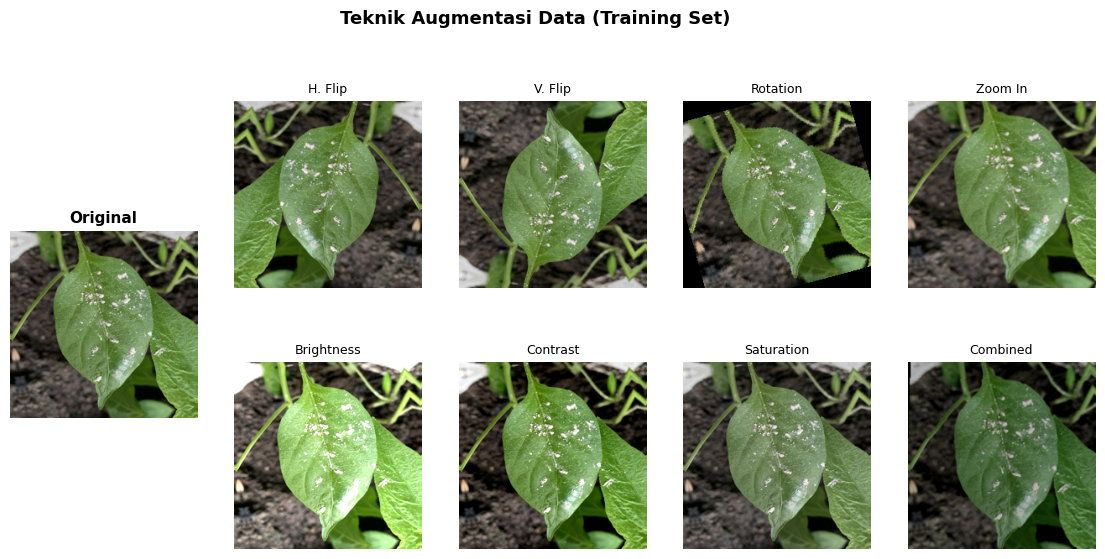

In [ ]:
print("="*50)
print("TAHAP 5 — AUGMENTASI ")
print("="*50)

# --- Augmentasi hanya untuk training ---
augmentation_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.RandomResizedCrop(
        size=IMG_SIZE, scale=(0.8, 1.0), ratio=(0.9, 1.1)
    ),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05
    ),
])

# Gabungan untuk training: Augmentasi → Preprocessing
train_transform = transforms.Compose([
    augmentation_transform,
    preprocessing_transform,
])

# Val & test: hanya Preprocessing
eval_transform = preprocessing_transform

# --- Custom Dataset ---
class CabaiDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)

# --- Dataset & DataLoader ---
train_dataset = CabaiDataset(train_paths, train_labels, train_transform)
val_dataset   = CabaiDataset(val_paths,   val_labels,   eval_transform)
test_dataset  = CabaiDataset(test_paths,  test_labels,  eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")

# --- Visualisasi Augmentasi ---
sample_img_path = train_paths[0]
original_img = Image.open(sample_img_path).convert('RGB')

fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.3, wspace=0.2)

ax_orig = fig.add_subplot(gs[:, 0])
ax_orig.imshow(original_img.resize((224, 224)))
ax_orig.set_title('Original', fontsize=11, fontweight='bold')
ax_orig.axis('off')

aug_list = [
    ('H. Flip',    transforms.RandomHorizontalFlip(p=1.0)),
    ('V. Flip',    transforms.RandomVerticalFlip(p=1.0)),
    ('Rotation',   transforms.RandomRotation(degrees=(15, 15))),
    ('Zoom In',    transforms.RandomResizedCrop(224, scale=(0.7, 0.8))),
    ('Brightness', transforms.ColorJitter(brightness=0.6)),
    ('Contrast',   transforms.ColorJitter(contrast=0.6)),
    ('Saturation', transforms.ColorJitter(saturation=0.6)),
    ('Combined',   train_transform),
]
positions = [(0,1),(0,2),(0,3),(0,4),(1,1),(1,2),(1,3),(1,4)]
for (r, c), (name, tfm) in zip(positions, aug_list):
    ax = fig.add_subplot(gs[r, c])
    aug = tfm(original_img.resize((224, 224)))
    if isinstance(aug, torch.Tensor):
        aug_np = aug.numpy().transpose(1,2,0)
        aug_np = aug_np * [0.229,0.224,0.225] + [0.485,0.456,0.406]
        aug_np = np.clip(aug_np, 0, 1)
        ax.imshow(aug_np)
    else:
        ax.imshow(aug)
    ax.set_title(name, fontsize=9)
    ax.axis('off')

plt.suptitle('Teknik Augmentasi Data (Training Set)', fontsize=13, y=1.02, fontweight='bold')
plt.savefig(SAVE_DIR / 'visualisasi_augmentasi.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

print("="*50)
print("TAHAP 6 — SETUP ARSITEKTUR MODEL")
print("="*50)


backbone = timm.create_model(
    'convnextv2_tiny.fcmae_ft_in22k_in1k',
    pretrained=True,
    num_classes=0
)

feature_dim = backbone.num_features

class ConvNeXtV2Cabai(nn.Module):
    def __init__(self, backbone, num_classes=5, dropout_rate=0.3):
        super().__init__()
        self.backbone   = backbone
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(feature_dim, num_classes)
        )
    def forward(self, x):
        feats = self.backbone(x)
        return self.classifier(feats)

model = ConvNeXtV2Cabai(backbone, NUM_CLASSES, DROPOUT_RATE).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"  Model       : ConvNeXt V2 Tiny")
print(f"  Feature dim : {feature_dim}")
print(f"  Total param : {total_params:,}")
print(f"  Output kelas: {NUM_CLASSES} ({', '.join(CLASS_NAMES)})")
print("  Model berhasil dibuat dan dipindah ke", device)

TAHAP 6 — SETUP ARSITEKTUR MODEL


model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

  Model       : ConvNeXt V2 Tiny
  Feature dim : 768
  Total param : 27,870,341
  Output kelas: 5 (daun sehat, leaf curl, yellowish, leaf spot, whitefly)
  Model berhasil dibuat dan dipindah ke cuda


In [ ]:

def train_one_epoch(model, loader, criterion, optimizer):
    """Satu epoch training. Return: (avg_loss, accuracy)"""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    """Evaluasi model pada satu loader. Return: (avg_loss, accuracy)"""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

# History untuk menyimpan metrik semua epoch
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

print("Helper functions siap digunakan.")

Helper functions siap digunakan.


In [ ]:


print("="*50)
print("TAHAP 7 — TRAINING FASE 1: FEATURE EXTRACTION")
print("="*50)

# Freeze backbone
for param in model.backbone.parameters():
    param.requires_grad = False

frozen    = sum(p.numel() for p in model.backbone.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Parameter di-freeze : {frozen:,}")
print(f"  Parameter dilatih   : {trainable:,}")

criterion      = nn.CrossEntropyLoss()
optimizer_p1   = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE1, weight_decay=WEIGHT_DECAY
)

best_val_acc_p1 = 0.0
patience_count  = 0
actual_epochs_p1 = 0

print(f"\n  {'Epoch':<8} {'Train Loss':<13} {'Train Acc':<13} {'Val Loss':<13} {'Val Acc':<13} {'Status'}")
print("  " + "-"*72)

for epoch in range(1, EPOCHS_PHASE1 + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer_p1)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    actual_epochs_p1 += 1
    status = ""

    if vl_acc > best_val_acc_p1:
        best_val_acc_p1 = vl_acc
        torch.save(model.state_dict(), '/content/best_phase1.pth')
        patience_count = 0
        status = "✓ Saved"
    else:
        patience_count += 1
        if patience_count >= PATIENCE_P1:
            status = "EarlyStopping"
            print(f"  {epoch:<8} {tr_loss:<13.4f} {tr_acc*100:<13.2f} {vl_loss:<13.4f} {vl_acc*100:<13.2f} {status}")
            break

    print(f"  {epoch:<8} {tr_loss:<13.4f} {tr_acc*100:<13.2f} {vl_loss:<13.4f} {vl_acc*100:<13.2f} {status}")

print(f"\n  Fase 1 selesai. Best Val Accuracy: {best_val_acc_p1*100:.2f}%")

TAHAP 7 — TRAINING FASE 1: FEATURE EXTRACTION
  Parameter di-freeze : 27,866,496
  Parameter dilatih   : 3,845

  Epoch    Train Loss    Train Acc     Val Loss      Val Acc       Status
  ------------------------------------------------------------------------
  1        0.7145        74.52         0.3302        90.95         ✓ Saved
  2        0.3087        91.90         0.2221        94.29         ✓ Saved
  3        0.2192        94.40         0.1866        96.19         ✓ Saved
  4        0.1797        95.42         0.1342        97.14         ✓ Saved
  5        0.1696        95.48         0.1286        97.62         ✓ Saved
  6        0.1364        96.49         0.1185        97.14         
  7        0.1326        96.19         0.1103        98.10         ✓ Saved
  8        0.1326        96.43         0.1114        96.67         
  9        0.1135        97.02         0.1119        96.19         
  10       0.1082        97.20         0.1040        98.10         

  Fase 1 selesai

In [ ]:


print("="*50)
print("TAHAP 8 — TRAINING FASE 2: FINE-TUNING")
print("="*50)

# Load bobot terbaik dari Fase 1
model.load_state_dict(torch.load('/content/best_phase1.pth'))

# Unfreeze seluruh backbone
for param in model.backbone.parameters():
    param.requires_grad = True

total_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Semua parameter aktif: {total_trainable:,}")
print(f"  LR backbone: {LR_BACKBONE_P2} | LR head: {LR_HEAD_P2}")

# Differential learning rate
optimizer_p2 = optim.AdamW([
    {'params': model.backbone.parameters(),   'lr': LR_BACKBONE_P2, 'weight_decay': WEIGHT_DECAY},
    {'params': model.classifier.parameters(), 'lr': LR_HEAD_P2,     'weight_decay': 0.01}
])

# ReduceLROnPlateau: kurangi LR otomatis jika val_loss stagnan
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode='min', factor=0.2, patience=3
)

best_val_acc_p2 = 0.0
patience_count  = 0

print(f"\n  {'Epoch':<8} {'Train Loss':<13} {'Train Acc':<13} {'Val Loss':<13} {'Val Acc':<13} {'Status'}")
print("  " + "-"*72)

for epoch in range(1, EPOCHS_PHASE2 + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer_p2)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    scheduler.step(vl_loss)
    status = ""

    if vl_acc > best_val_acc_p2:
        best_val_acc_p2 = vl_acc
        torch.save(model.state_dict(), '/content/best_model_final.pth')
        # Salin ke Drive agar tidak hilang jika Colab disconnect
        torch.save({
            'model_state_dict' : model.state_dict(),
            'class_names'      : CLASS_NAMES,
            'best_val_accuracy': best_val_acc_p2,
        }, SAVE_DIR / 'convnextv2_cabai_final.pth')
        patience_count = 0
        status = "✓ Saved"
    else:
        patience_count += 1
        if patience_count >= PATIENCE_P2:
            status = "EarlyStopping"
            print(f"  {epoch:<8} {tr_loss:<13.4f} {tr_acc*100:<13.2f} {vl_loss:<13.4f} {vl_acc*100:<13.2f} {status}")
            break

    print(f"  {epoch:<8} {tr_loss:<13.4f} {tr_acc*100:<13.2f} {vl_loss:<13.4f} {vl_acc*100:<13.2f} {status}")

print(f"\n  Fase 2 selesai. Best Val Accuracy: {best_val_acc_p2*100:.2f}%")
print(f"  Model disimpan ke: {SAVE_DIR}/convnextv2_cabai_final.pth")


TAHAP 8 — TRAINING FASE 2: FINE-TUNING
  Semua parameter aktif: 27,870,341
  LR backbone: 5e-06 | LR head: 0.0001

  Epoch    Train Loss    Train Acc     Val Loss      Val Acc       Status
  ------------------------------------------------------------------------
  1        0.0994        97.50         0.0825        97.62         ✓ Saved
  2        0.0704        97.74         0.0706        97.14         
  3        0.0573        98.27         0.0660        98.10         ✓ Saved
  4        0.0489        98.63         0.0602        98.10         
  5        0.0381        98.87         0.0608        97.14         
  6        0.0378        98.75         0.0598        97.62         
  7        0.0310        99.17         0.0688        97.14         
  8        0.0353        98.69         0.0663        97.62         
  9        0.0259        99.40         0.0617        98.10         
  10       0.0215        99.58         0.0637        97.62         
  11       0.0221        99.35         0.0

TAHAP 9a — GRAFIK TRAINING HISTORY


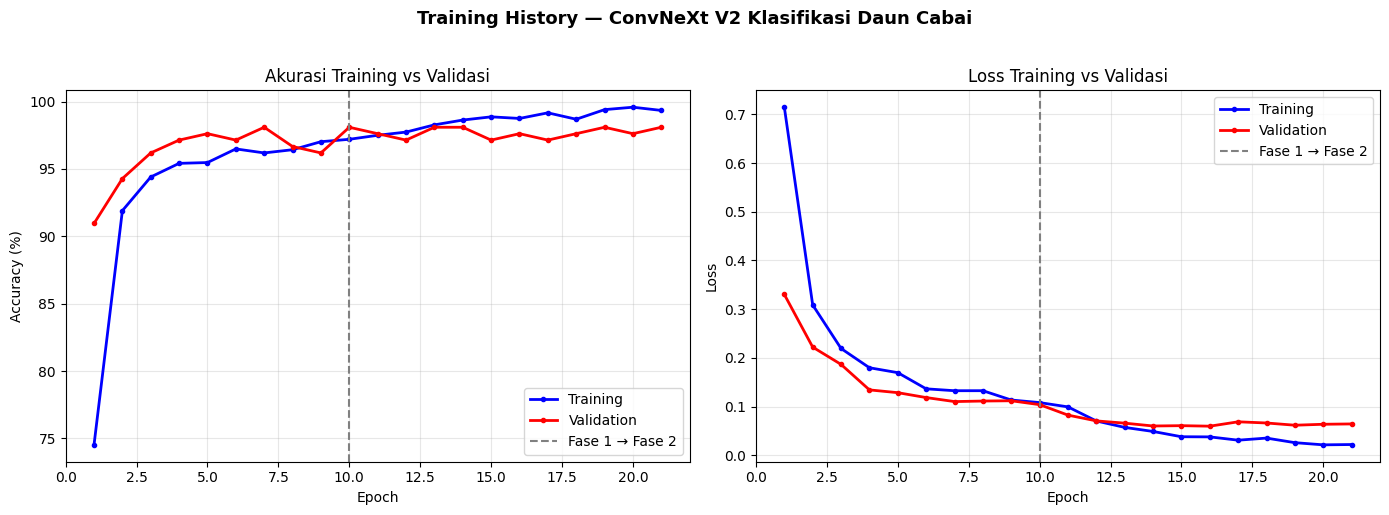

  Grafik disimpan: training_history.png


In [ ]:

print("="*50)
print("TAHAP 9a — GRAFIK TRAINING HISTORY")
print("="*50)

total_epochs = len(history['train_loss'])
epochs_range = range(1, total_epochs + 1)
p1_end       = actual_epochs_p1   # epoch terakhir Fase 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Akurasi
ax1.plot(epochs_range, [a*100 for a in history['train_acc']],
         'b-o', ms=3, lw=2, label='Training')
ax1.plot(epochs_range, [a*100 for a in history['val_acc']],
         'r-o', ms=3, lw=2, label='Validation')
ax1.axvline(x=p1_end, color='gray', linestyle='--', lw=1.5, label='Fase 1 → Fase 2')
ax1.set_title('Akurasi Training vs Validasi', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(alpha=0.3)

# Loss
ax2.plot(epochs_range, history['train_loss'],
         'b-o', ms=3, lw=2, label='Training')
ax2.plot(epochs_range, history['val_loss'],
         'r-o', ms=3, lw=2, label='Validation')
ax2.axvline(x=p1_end, color='gray', linestyle='--', lw=1.5, label='Fase 1 → Fase 2')
ax2.set_title('Loss Training vs Validasi', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle(
    'Training History — ConvNeXt V2 Klasifikasi Daun Cabai',
    fontsize=13, y=1.02, fontweight='bold'
)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Grafik disimpan: training_history.png")

TAHAP 9b — EVALUASI FINAL DI TEST SET

  CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  daun sehat     0.9545    1.0000    0.9767        42
   leaf curl     0.9286    0.9286    0.9286        42
   yellowish     0.9302    0.9524    0.9412        42
   leaf spot     0.9762    0.9762    0.9762        42
    whitefly     1.0000    0.9286    0.9630        42

    accuracy                         0.9571       210
   macro avg     0.9579    0.9571    0.9571       210
weighted avg     0.9579    0.9571    0.9571       210



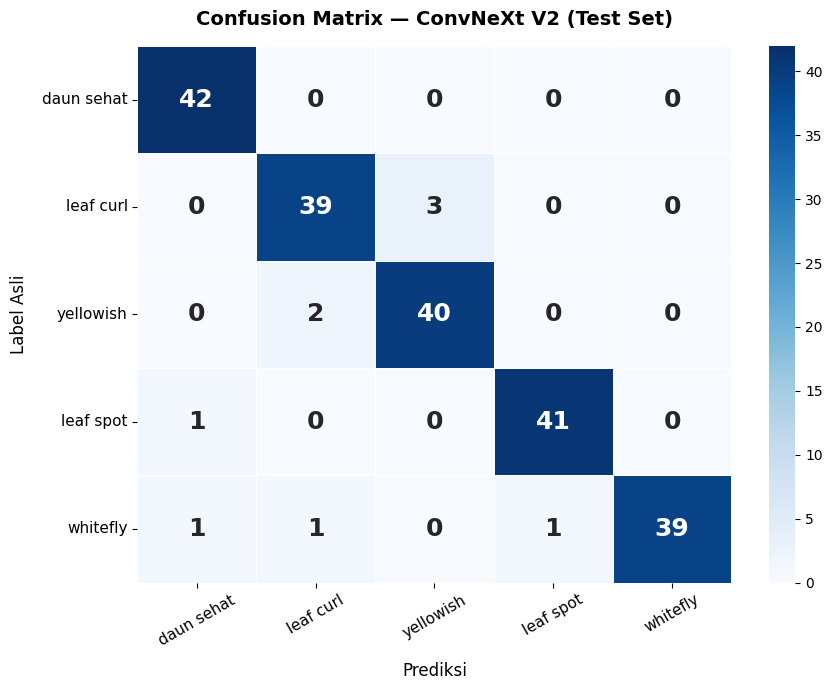

  Confusion matrix disimpan: confusion_matrix.png

  Pasangan kelas yang sering tertukar:
  Kelas Asli         Diprediksi Sebagai      Jumlah
  --------------------------------------------------
  leaf curl          yellowish                  3  (7.1%)
  yellowish          leaf curl                  2  (4.8%)
  leaf spot          daun sehat                 1  (2.4%)
  whitefly           daun sehat                 1  (2.4%)
  whitefly           leaf curl                  1  (2.4%)
  whitefly           leaf spot                  1  (2.4%)


In [ ]:
print("="*50)
print("TAHAP 9b — EVALUASI FINAL DI TEST SET")
print("="*50)

# Load model terbaik
model.load_state_dict(torch.load('/content/best_model_final.pth'))
model.eval()

all_preds, all_true, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs    = imgs.to(device)
        outputs = model(imgs)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)
all_probs = np.array(all_probs)

# --- Classification Report ---
print("\n  CLASSIFICATION REPORT:")
print(classification_report(
    all_true, all_preds,
    target_names=[c.replace('_', ' ') for c in CLASS_NAMES],
    digits=4
))

# --- Confusion Matrix (angka saja) ---
cm            = confusion_matrix(all_true, all_preds)
kelas_display = [c.replace('_', ' ') for c in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas_display,
    yticklabels=kelas_display,
    ax=ax,
    linewidths=0.5,
    annot_kws={"size": 18, "weight": "bold"}   # ← angka diperbesar
)

ax.set_title('Confusion Matrix — ConvNeXt V2 (Test Set)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Prediksi', fontsize=12, labelpad=10)
ax.set_ylabel('Label Asli', fontsize=12, labelpad=10)
ax.tick_params(axis='x', rotation=30, labelsize=11)
ax.tick_params(axis='y', rotation=0,  labelsize=11)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Confusion matrix disimpan: confusion_matrix.png")

# --- Pasangan kelas paling sering tertukar ---
print("\n  Pasangan kelas yang sering tertukar:")
print(f"  {'Kelas Asli':<18} {'Diprediksi Sebagai':<22} {'Jumlah':>7}")
print("  " + "-"*50)
errors = [
    (CLASS_NAMES[i], CLASS_NAMES[j], cm[i, j])
    for i in range(NUM_CLASSES)
    for j in range(NUM_CLASSES)
    if i != j and cm[i, j] > 0
]
for a, b, c in sorted(errors, key=lambda x: x[2], reverse=True)[:8]:
    pct = c / cm[CLASS_NAMES.index(a)].sum() * 100
    print(f"  {a:<18} {b:<22} {c:>5}  ({pct:.1f}%)")

TAHAP 9c — ROC-AUC CURVE


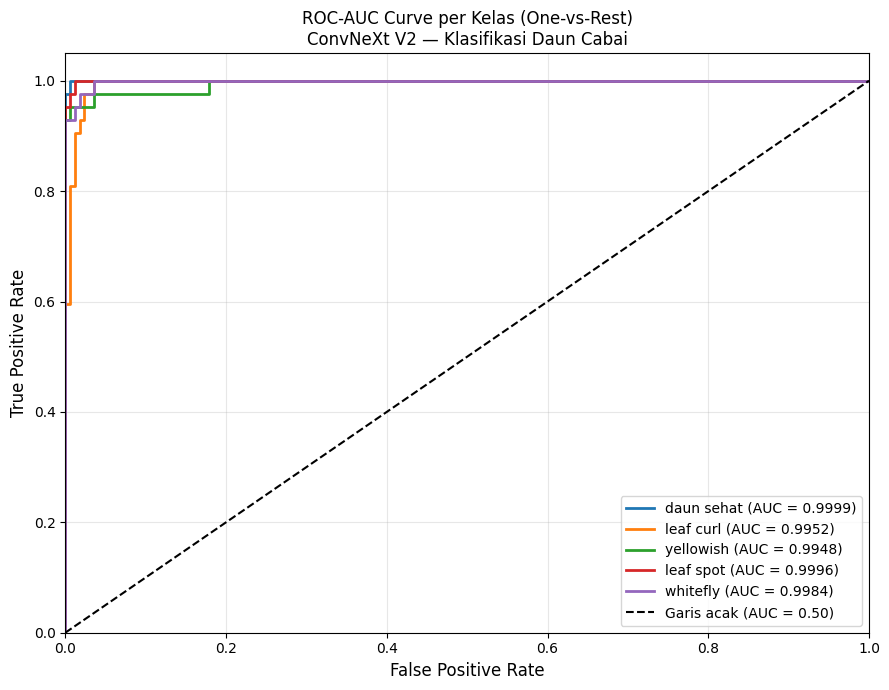


  AUC per kelas:
    daun sehat        : 0.9999
    leaf curl         : 0.9952
    yellowish         : 0.9948
    leaf spot         : 0.9996
    whitefly          : 0.9984

  Macro-Average AUC : 0.9976
  ROC-AUC curve disimpan: roc_auc_curveaugmentasi.png


In [ ]:

print("="*50)
print("TAHAP 9c — ROC-AUC CURVE")
print("="*50)

y_bin = label_binarize(all_true, classes=list(range(NUM_CLASSES)))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

plt.figure(figsize=(9, 7))
auc_scores = {}

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores[cls] = roc_auc
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cls.replace("_"," ")} (AUC = {roc_auc:.4f})')

plt.plot([0,1],[0,1],'k--', lw=1.5, label='Garis acak (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC Curve per Kelas (One-vs-Rest)\nConvNeXt V2 — Klasifikasi Daun Cabai',
          fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'roc_auc_curveaugmentasi.png', dpi=150)
plt.show()

macro_auc = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')
print(f"\n  AUC per kelas:")
for cls, score in auc_scores.items():
    print(f"    {cls:<18}: {score:.4f}")
print(f"\n  Macro-Average AUC : {macro_auc:.4f}")
print("  ROC-AUC curve disimpan: roc_auc_curveaugmentasi.png")


TAHAP 9d — GRAD-CAM VISUALISASI


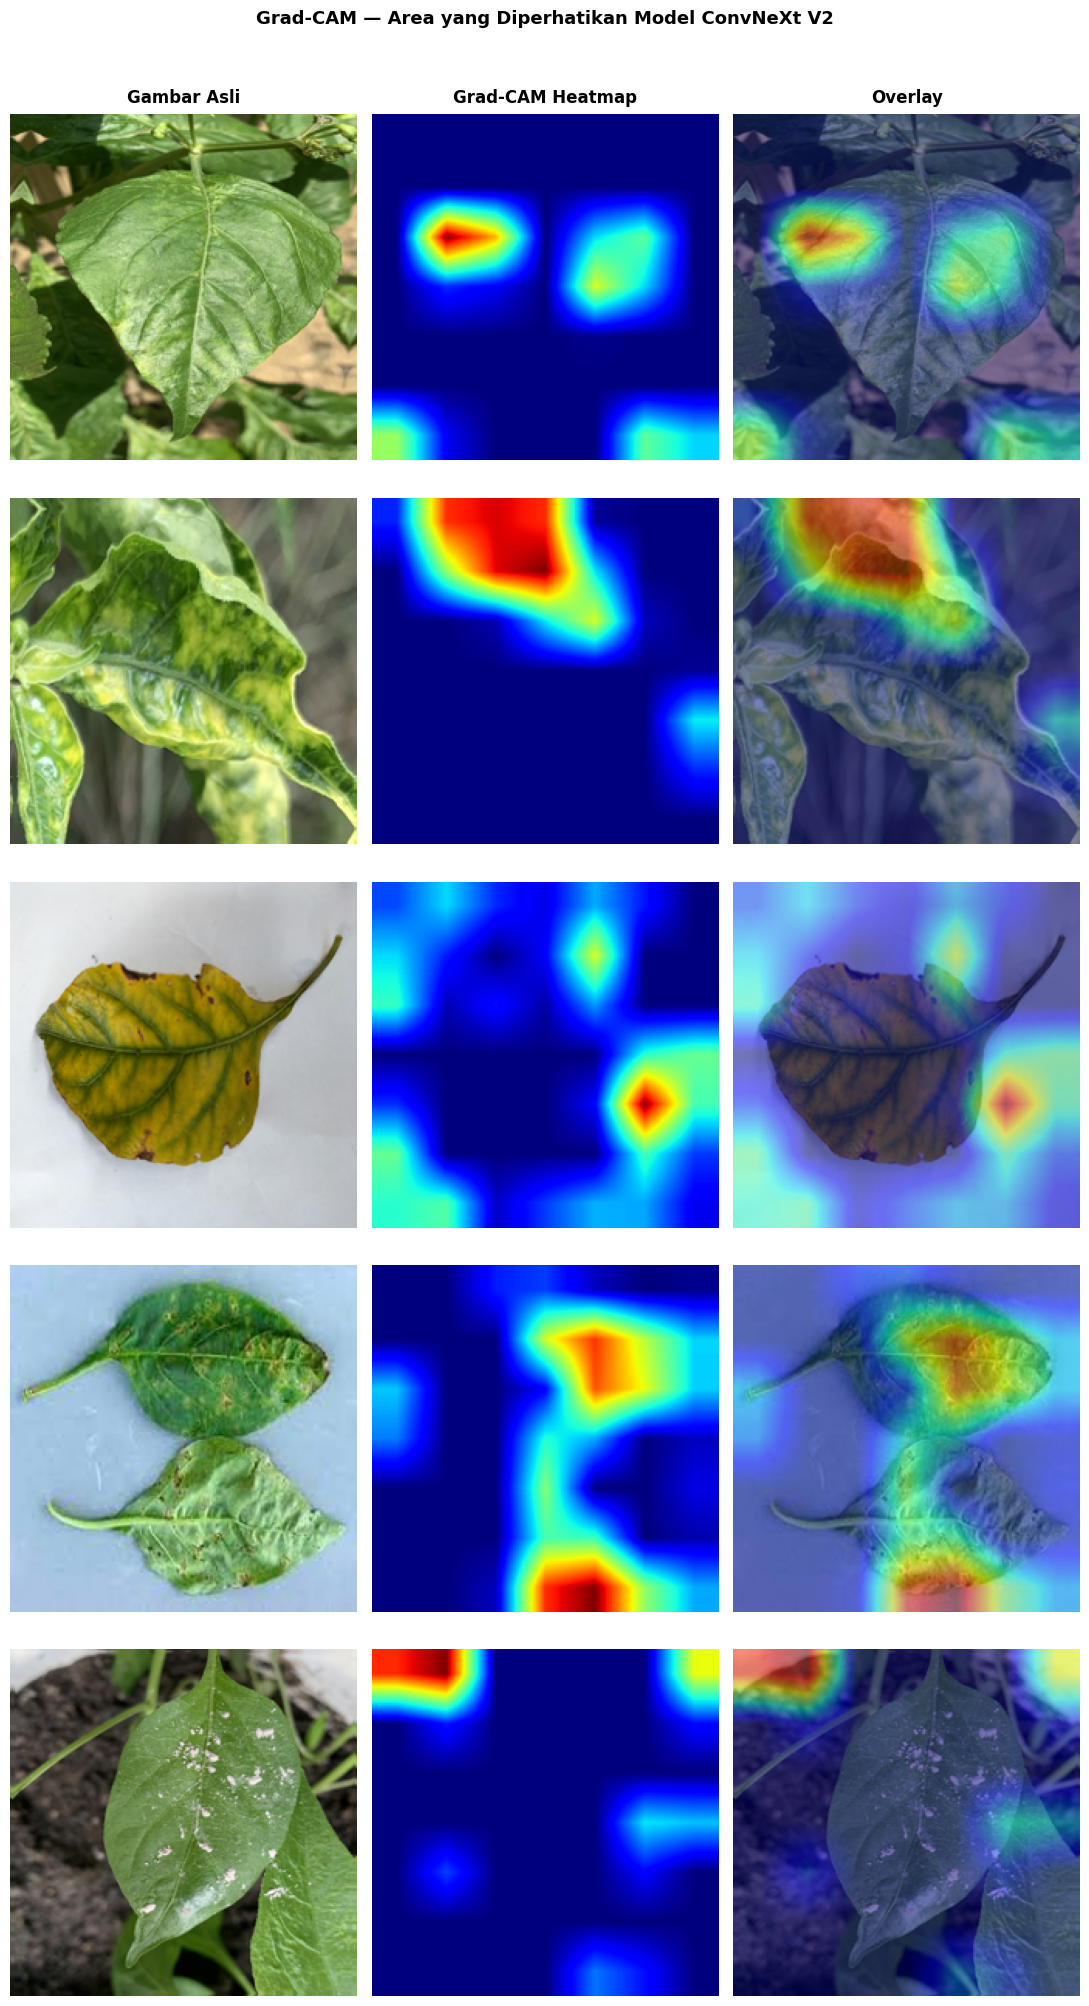

  Grad-CAM disimpan: gradcam_visualisasiaugmentasi.png


In [ ]:

print("="*50)
print("TAHAP 9d — GRAD-CAM VISUALISASI")
print("="*50)

import cv2
import matplotlib.cm as mpl_cm

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, class_idx] = 1.0
        output.backward(gradient=one_hot, retain_graph=True)
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam).squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

def make_overlay(img_pil, cam, alpha=0.5):
    img_np      = np.array(img_pil.resize((224,224))).astype(np.float32) / 255.0
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap     = mpl_cm.jet(cam_resized)[:,:,:3]
    overlay     = np.clip(alpha * heatmap + (1-alpha) * img_np, 0, 1)
    return overlay, heatmap

# Target layer: blok depthwise conv terakhir backbone
target_layer = model.backbone.stages[-1].blocks[-1].conv_dw
gradcam      = GradCAM(model, target_layer)

# Ambil 1 gambar per kelas dari test set
sample_per_class = {}
for path, label in zip(test_paths, test_labels):
    if label not in sample_per_class:
        sample_per_class[label] = path
    if len(sample_per_class) == NUM_CLASSES:
        break

gradcam_paths = [sample_per_class[i] for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(11, 4*NUM_CLASSES))
for ax, title in zip(axes[0], ['Gambar Asli', 'Grad-CAM Heatmap', 'Overlay']):
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)

for i, img_path in enumerate(gradcam_paths):
    img_pil    = Image.open(img_path).convert('RGB')
    img_tensor = eval_transform(img_pil).unsqueeze(0).to(device)
    img_tensor.requires_grad_(True)
    cam, pred_idx   = gradcam.generate(img_tensor)
    overlay, heatmap = make_overlay(img_pil, cam)

    axes[i, 0].imshow(img_pil.resize((224,224)))
    axes[i, 0].set_ylabel(
        CLASS_NAMES[pred_idx].replace('_',' '),
        fontsize=10, rotation=0, labelpad=70, va='center'
    )
    axes[i, 0].axis('off')
    axes[i, 1].imshow(heatmap)
    axes[i, 1].axis('off')
    axes[i, 2].imshow(overlay)
    axes[i, 2].axis('off')

plt.suptitle('Grad-CAM — Area yang Diperhatikan Model ConvNeXt V2',
             fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'gradcam_visualisasiaugmentasi.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Grad-CAM disimpan: gradcam_visualisasiaugmentasi.png")


In [ ]:
print("="*55)
print("RINGKASAN HASIL AKHIR — BAB 4 SKRIPSI")
print("="*55)

acc       = accuracy_score(all_true, all_preds)
precision = precision_score(all_true, all_preds, average='macro', zero_division=0)
recall    = recall_score(all_true, all_preds, average='macro', zero_division=0)
f1        = f1_score(all_true, all_preds, average='macro', zero_division=0)

print(f"""
  ┌──────────────────────────────────────────────┐
  │   HASIL EVALUASI — ConvNeXt V2 Tiny          │
  │   Klasifikasi Penyakit & Hama Daun Cabai     │
  ├──────────────────────────────────────────────┤
  │   Accuracy         : {acc*100:>8.4f} %             │
  │   Precision (macro): {precision*100:>8.4f} %             │
  │   Recall (macro)   : {recall*100:>8.4f} %             │
  │   F1-Score (macro) : {f1*100:>8.4f} %             │
  │   ROC-AUC (macro)  : {macro_auc:>8.4f}               │
  ├──────────────────────────────────────────────┤
  │   Total test image : {len(test_paths):>5}                      │
  │   Benar            : {len(test_paths)-int(len(test_paths)*(1-acc)):>5}                      │
  │   Salah            : {int(len(test_paths)*(1-acc)):>5}                      │
  └──────────────────────────────────────────────┘
""")

report_dict = classification_report(
    all_true, all_preds,
    target_names=CLASS_NAMES, output_dict=True, zero_division=0
)
print(f"  {'Kelas':<18} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>9}")
print("  " + "-"*62)
for cls in CLASS_NAMES:
    p = report_dict[cls]['precision'] * 100
    r = report_dict[cls]['recall']    * 100
    f = report_dict[cls]['f1-score']  * 100
    s = int(report_dict[cls]['support'])
    print(f"  {cls:<18} {p:>9.2f}% {r:>9.2f}% {f:>9.2f}% {s:>8}")

RINGKASAN HASIL AKHIR — BAB 4 SKRIPSI

  ┌──────────────────────────────────────────────┐
  │   HASIL EVALUASI — ConvNeXt V2 Tiny          │
  │   Klasifikasi Penyakit & Hama Daun Cabai     │
  ├──────────────────────────────────────────────┤
  │   Accuracy         :  95.7143 %             │
  │   Precision (macro):  95.7908 %             │
  │   Recall (macro)   :  95.7143 %             │
  │   F1-Score (macro) :  95.7129 %             │
  │   ROC-AUC (macro)  :   0.9976               │
  ├──────────────────────────────────────────────┤
  │   Total test image :   210                      │
  │   Benar            :   202                      │
  │   Salah            :     8                      │
  └──────────────────────────────────────────────┘

  Kelas               Precision     Recall   F1-Score   Support
  --------------------------------------------------------------
  daun sehat             95.45%    100.00%     97.67%       42
  leaf curl              92.86%     92.86%     92.

Silakan upload gambar daun cabai (.jpg / .jpeg / .png) ...


Saving download (6).jpg to download (6).jpg

 Memproses: download (6).jpg


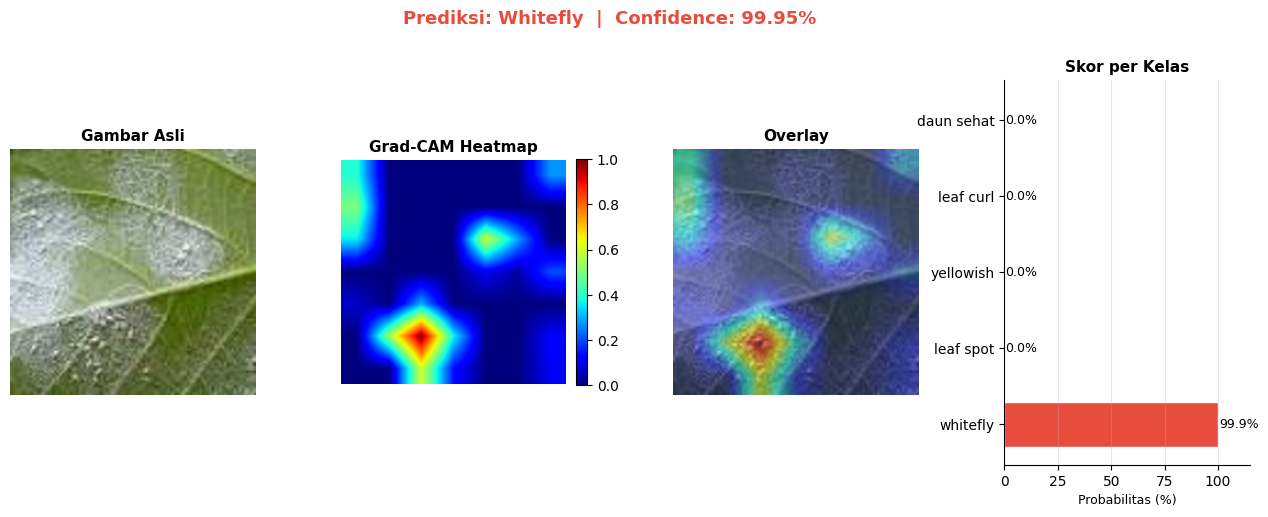


✅ Prediksi : Whitefly
   Confidence: 99.95%
   Disimpan  : /content/drive/MyDrive/hasil_skripsi/inferensi_whitefly.png


In [ ]:
# ============================================================
# TAHAP 10 — INFERENSI & GRAD-CAM PADA GAMBAR BARU (UPLOAD)
# ============================================================
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch
import cv2
import io

# ── Grad-CAM class (ConvNeXt V2 compatible) ─────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.target_layer = target_layer
        self.gradients   = None
        self.activations = None
        self._hooks      = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self._hooks.append(
            self.target_layer.register_forward_hook(forward_hook))
        self._hooks.append(
            self.target_layer.register_full_backward_hook(backward_hook))

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.unsqueeze(0).to(device)
        input_tensor.requires_grad_(True)

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        # Pooled gradients
        grads  = self.gradients[0]          # (C, H, W)
        acts   = self.activations[0]        # (C, H, W)
        weights = grads.mean(dim=(1, 2))    # (C,)

        cam = (weights[:, None, None] * acts).sum(dim=0)
        cam = torch.relu(cam).cpu().numpy()

        # Normalize
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        else:
            cam = np.zeros_like(cam)

        return cam, class_idx, torch.softmax(output, dim=1)[0].detach().cpu().numpy()


def overlay_gradcam(original_pil, cam, alpha=0.45):
    """Tempel heatmap di atas gambar asli."""
    img_np = np.array(original_pil.resize((224, 224)))
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = np.uint8(alpha * heatmap + (1 - alpha) * img_np)
    return overlay


def run_inference_and_gradcam(image_path_or_pil):
    # ── Load & preprocess ────────────────────────────────────
    if isinstance(image_path_or_pil, str):
        pil_img = Image.open(image_path_or_pil).convert('RGB')
    else:
        pil_img = image_path_or_pil.convert('RGB')

    input_tensor = preprocessing_transform(pil_img)   # eval transform

    # ── Pilih target layer (stages[-1] ConvNeXt V2) ─────────
    target_layer = model.backbone.stages[-1]
    gradcam      = GradCAM(model, target_layer)

    cam, pred_idx, probs = gradcam.generate(input_tensor)
    gradcam.remove_hooks()

    pred_label = CLASS_NAMES[pred_idx].replace('_', ' ').title()
    confidence = probs[pred_idx] * 100
    overlay    = overlay_gradcam(pil_img, cam)

    # ── Plot ────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 5))
    gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

    # Panel 1: Gambar Asli
    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(pil_img.resize((224, 224)))
    ax0.set_title('Gambar Asli', fontsize=11, fontweight='bold')
    ax0.axis('off')

    # Panel 2: Grad-CAM Heatmap
    cam_resized = cv2.resize(cam, (224, 224))
    ax1 = fig.add_subplot(gs[1])
    im  = ax1.imshow(cam_resized, cmap='jet', vmin=0, vmax=1)
    ax1.set_title('Grad-CAM Heatmap', fontsize=11, fontweight='bold')
    ax1.axis('off')
    plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

    # Panel 3: Overlay
    ax2 = fig.add_subplot(gs[2])
    ax2.imshow(overlay)
    ax2.set_title('Overlay', fontsize=11, fontweight='bold')
    ax2.axis('off')

    # Panel 4: Bar chart probabilitas semua kelas
    ax3 = fig.add_subplot(gs[3])
    labels_k = [c.replace('_', ' ') for c in CLASS_NAMES]
    colors_bar = ['#e74c3c' if i == pred_idx else '#2ecc71'
                  for i in range(len(CLASS_NAMES))]
    bars = ax3.barh(labels_k, probs * 100, color=colors_bar,
                    edgecolor='white', height=0.6)
    for bar, p in zip(bars, probs * 100):
        ax3.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{p:.1f}%', va='center', fontsize=9)
    ax3.set_xlim(0, 115)
    ax3.set_xlabel('Probabilitas (%)', fontsize=9)
    ax3.set_title('Skor per Kelas', fontsize=11, fontweight='bold')
    ax3.invert_yaxis()
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.grid(axis='x', alpha=0.3)

    fig.suptitle(
        f'Prediksi: {pred_label}  |  Confidence: {confidence:.2f}%',
        fontsize=13, fontweight='bold', y=1.02,
        color='#e74c3c' if pred_idx != 0 else '#27ae60'
    )
    plt.tight_layout()

    save_path = SAVE_DIR / f'inferensi_{pred_label.replace(" ","_").lower()}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Prediksi : {pred_label}")
    print(f"   Confidence: {confidence:.2f}%")
    print(f"   Disimpan  : {save_path}")

    return pred_label, confidence


# ── Upload & jalankan ────────────────────────────────────────
print("Silakan upload gambar daun cabai (.jpg / .jpeg / .png) ...")
uploaded = files.upload()

for fname, fdata in uploaded.items():
    print(f"\n{'='*55}")
    print(f" Memproses: {fname}")
    print(f"{'='*55}")
    pil_img = Image.open(io.BytesIO(fdata))
    run_inference_and_gradcam(pil_img)